# 🌍 WORLD POPULATION ANALYSIS - TIME-SERIES & GEOGRAPHIC INSIGHTS

## Dataset: World Population Dataset
**Kaynak:** https://www.kaggle.com/datasets/iamsouravbanerjee/world-population-dataset

## 🎯 Proje Hedefi: DUNYA NUFUSU ANALIZI & TAHMINLEME

## 🌟 Proje Ozellikleri:
- **Time-Series Analysis** - Temporal trends & patterns
- **Geographic Analysis** - Continent/Country comparisons
- **Growth Rate Predictions** - Population forecasting
- **Demographic Insights** - Population density, distribution
- **Forecasting Models** - ARIMA, Prophet, ML models
- **Clustering Analysis** - Country grouping by patterns
- **30+ Visualizations** - Time-series, maps, rankings
- **Interactive Plotly Graphs** - Dynamic exploration

## 📋 Proje Adimlari:
1. Veri Yukleme & Temporal Structure
2. **TEMPORAL EDA** (20+ time-series graphs)
3. **GEOGRAPHIC EDA** (Continental/Regional analysis)
4. Growth Rate & Trend Analysis
5. **FORECASTING MODELS** (ARIMA, Prophet, ML)
6. **CLUSTERING ANALYSIS** (Country groups)
7. **COMPREHENSIVE COMPARISON** (Visual + Rankings)
8. Demographic Insights & Future Projections

## 1️⃣ KUTUPHANE YUKLEME

In [1]:
# Temel
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Sistem
import os
import subprocess
import zipfile
import glob

# Time series
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.decomposition import PCA

# Plotly
try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    PLOTLY = True
except:
    PLOTLY = False
    print('Plotly yuklenemedi')

# Prophet
try:
    from prophet import Prophet
    PROPHET = True
except:
    PROPHET = False
    print('Prophet yuklenemedi - pip install prophet')

# Viz
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (14, 6)
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print('='*80)
print('🌍 WORLD POPULATION ANALYSIS - KUTUPHANELER YUKLENDI!')
print('='*80)
print(f'NumPy: {np.__version__}')
print(f'Pandas: {pd.__version__}')
print(f'Plotly: {"Available" if PLOTLY else "Not Available"}')
print(f'Prophet: {"Available" if PROPHET else "Not Available"}')
print('='*80)

🌍 WORLD POPULATION ANALYSIS - KUTUPHANELER YUKLENDI!
NumPy: 2.0.2
Pandas: 2.2.2
Plotly: Available
Prophet: Available


## 2️⃣ VERI YUKLEME

In [2]:
def download_dataset_direct(download_url, dest_folder, zip_filename):
    if not os.path.exists(dest_folder):
        os.makedirs(dest_folder)

    full_zip_path = os.path.join(dest_folder, zip_filename)
    print(f"\n{'='*80}")
    print(f"🌍 INDIRILIYOR: {zip_filename}")
    print(f"{'='*80}")

    try:
        cmd = ["wget", "-O", full_zip_path, download_url]
        subprocess.run(cmd, check=True)
        return True
    except:
        return False

def extract_dataset(dest_folder):
    try:
        zip_files = glob.glob(os.path.join(dest_folder, "*.zip"))
        for zip_file in zip_files:
            with zipfile.ZipFile(zip_file, 'r') as zip_ref:
                zip_ref.extractall(dest_folder)
            os.remove(zip_file)
        return True
    except:
        return False

In [3]:
# Dataset indirme
dataset_folder = "world_population_dataset"
os.makedirs(dataset_folder, exist_ok=True)

dataset_info = {
    "download_url": "https://www.kaggle.com/api/v1/datasets/download/iamsouravbanerjee/world-population-dataset",
    "folder": dataset_folder,
    "zip_filename": "world-population.zip"
}

csv_files = glob.glob(os.path.join(dataset_folder, "*.csv"))

if not csv_files:
    success = download_dataset_direct(
        dataset_info["download_url"],
        dataset_info["folder"],
        dataset_info["zip_filename"]
    )
    if success:
        extract_dataset(dataset_info["folder"])
else:
    print("✅ Dataset zaten mevcut!")


🌍 INDIRILIYOR: world-population.zip


In [4]:
# Veri yukleme
csv_files = glob.glob(os.path.join(dataset_folder, "*.csv"))

if csv_files:
    print(f'\n📁 Bulunan CSV dosyalari:')
    for i, f in enumerate(csv_files):
        print(f'  {i+1}. {os.path.basename(f)}')

    df = pd.read_csv(csv_files[0])

    print('\n' + '='*80)
    print('✅ VERI YUKLENDI!')
    print('='*80)
    print(f'📊 Toplam Kayit: {len(df):,}')
    print(f'📊 Sutun Sayisi: {len(df.columns)}')
    print(f'💾 Bellek: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
    print('='*80)
else:
    print('❌ CSV dosyasi bulunamadi!')


📁 Bulunan CSV dosyalari:
  1. world_population.csv

✅ VERI YUKLENDI!
📊 Toplam Kayit: 234
📊 Sutun Sayisi: 17
💾 Bellek: 0.07 MB


In [5]:
# Ilk bakis
print('\n🌍 ILK 10 KAYIT:')
df.head(10)


🌍 ILK 10 KAYIT:


,Rank,CCA3,Country/Territory,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
0,36,AFG,Afghanistan,Kabul,Asia,41128771,38972230,33753499,28189672,19542982,10694796,12486631,10752971,652230,63.06,1.03,0.52
1,138,ALB,Albania,Tirana,Europe,2842321,2866849,2882481,2913399,3182021,3295066,2941651,2324731,28748,98.87,1.00,0.04
2,34,DZA,Algeria,Algiers,Africa,44903225,43451666,39543154,35856344,30774621,25518074,18739378,13795915,2381741,18.85,1.02,0.56
3,213,ASM,American Samoa,Pago Pago,Oceania,44273,46189,51368,54849,58230,47818,32886,27075,199,222.48,0.98,0.00
4,203,AND,Andorra,Andorra la Vella,Europe,79824,77700,71746,71519,66097,53569,35611,19860,468,170.56,1.01,0.00
5,42,AGO,Angola,Luanda,Africa,35588987,33428485,28127721,23364185,16394062,11828638,8330047,6029700,1246700,28.55,1.03,0.45
6,224,AIA,Anguilla,The Valley,North America,15857,15585,14525,13172,11047,8316,6560,6283,91,174.25,1.01,0.00
7,201,ATG,Antigua and Barbuda,Saint John’s,North America,93763,92664,89941,85695,75055,63328,64888,64516,442,212.13,1.01,0.00
8,33,ARG,Argentina,Buenos Aires,South America,45510318,45036032,43257065,41100123,37070774,32637657,28024803,23842803,2780400,16.37,1.01,0.57
9,140,ARM,Armenia,Yerevan,Asia,2780469,2805608,2878595,2946293,3168523,3556539,3135123,2534377,29743,93.48,1.00,0.03


In [6]:
# Veri yapisi
print('\n📊 VERI YAPISI:')
print('='*80)
df.info()


📊 VERI YAPISI:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Rank                         234 non-null    int64  
 1   CCA3                         234 non-null    object 
 2   Country/Territory            234 non-null    object 
 3   Capital                      234 non-null    object 
 4   Continent                    234 non-null    object 
 5   2022 Population              234 non-null    int64  
 6   2020 Population              234 non-null    int64  
 7   2015 Population              234 non-null    int64  
 8   2010 Population              234 non-null    int64  
 9   2000 Population              234 non-null    int64  
 10  1990 Population              234 non-null    int64  
 11  1980 Population              234 non-null    int64  
 12  1970 Population              234 non-null    int64  
 13  Area

In [7]:
# Sutun isimleri
print('\n📋 SUTUN ISIMLERI:')
for i, col in enumerate(df.columns, 1):
    print(f'{i:2d}. {col}')


📋 SUTUN ISIMLERI:
 1. Rank
 2. CCA3
 3. Country/Territory
 4. Capital
 5. Continent
 6. 2022 Population
 7. 2020 Population
 8. 2015 Population
 9. 2010 Population
10. 2000 Population
11. 1990 Population
12. 1980 Population
13. 1970 Population
14. Area (km²)
15. Density (per km²)
16. Growth Rate
17. World Population Percentage


In [8]:
# Istatistiksel ozet
print('\n📈 ISTATISTIKSEL OZET:')
print('='*80)
df.describe().T


📈 ISTATISTIKSEL OZET:


,count,mean,std,min,25%,50%,75%,max
Rank,234.00,117.50,67.69,1.00,59.25,117.50,175.75,234.00
2022 Population,234.00,34074414.71,136766424.80,510.00,419738.50,5559944.50,22476504.75,1425887337.00
2020 Population,234.00,33501070.95,135589876.92,520.00,415284.50,5493074.50,21447979.50,1424929781.00
2015 Population,234.00,31729956.24,130404992.75,564.00,404676.00,5307400.00,19730853.75,1393715448.00
2010 Population,234.00,29845235.03,124218487.63,596.00,393149.00,4942770.50,19159567.50,1348191368.00
2000 Population,234.00,26269468.82,111698206.72,651.00,327242.00,4292907.00,15762301.00,1264099069.00
1990 Population,234.00,22710220.79,97832173.35,700.00,264115.75,3825409.50,11869231.00,1153704252.00
1980 Population,234.00,18984616.97,81785186.08,733.00,229614.25,3141145.50,9826053.75,982372466.00
1970 Population,234.00,15786908.81,67795091.64,752.00,155997.00,2604830.00,8817329.00,822534450.00
Area (km²),234.00,581449.38,1761840.86,1.00,2650.00,81199.50,430425.75,17098242.00


## 3️⃣ TEMPORAL EDA - TIME-SERIES ANALYSIS

### 📅 Temporal Structure Analysis

In [9]:
# Yil sutunlarini bul
year_cols = [col for col in df.columns if col.isdigit() or 'population' in col.lower()]
year_cols = sorted([col for col in year_cols if str(col).isdigit()])

print('='*80)
print('📅 TEMPORAL STRUCTURE')
print('='*80)
print(f'\nYil Sutunlari: {len(year_cols)}')
if year_cols:
    print(f'Ilk Yil: {year_cols[0]}')
    print(f'Son Yil: {year_cols[-1]}')
    print(f'Yil Araligi: {int(year_cols[-1]) - int(year_cols[0]) + 1} yil')
    print(f'\nYillar: {year_cols[:5]} ... {year_cols[-5:]}')

# Diger onemli sutunlar
country_col = [col for col in df.columns if 'country' in col.lower()]
continent_col = [col for col in df.columns if 'continent' in col.lower()]
area_col = [col for col in df.columns if 'area' in col.lower()]
density_col = [col for col in df.columns if 'density' in col.lower()]

print(f'\n🌍 Geographic Columns:')
print(f'  Country: {country_col[0] if country_col else "Not found"}')
print(f'  Continent: {continent_col[0] if continent_col else "Not found"}')
print(f'  Area: {area_col[0] if area_col else "Not found"}')
print(f'  Density: {density_col[0] if density_col else "Not found"}')
print('='*80)

📅 TEMPORAL STRUCTURE

Yil Sutunlari: 0

🌍 Geographic Columns:
  Country: Country/Territory
  Continent: Continent
  Area: Area (km²)
  Density: Density (per km²)


### 🌍 Global Population Over Time

In [10]:
# Global population trend
if year_cols:
    global_pop = df[year_cols].sum()
    years = [int(y) for y in year_cols]

    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    fig.suptitle('🌍 GLOBAL POPULATION TRENDS', fontsize=18, fontweight='bold')

    # Line plot
    axes[0, 0].plot(years, global_pop.values / 1e9,
                   linewidth=3, color='steelblue', marker='o')
    axes[0, 0].set_xlabel('Year', fontweight='bold')
    axes[0, 0].set_ylabel('Population (Billions)', fontweight='bold')
    axes[0, 0].set_title('Global Population Growth', fontweight='bold', fontsize=14)
    axes[0, 0].grid(alpha=0.3)
    axes[0, 0].fill_between(years, global_pop.values / 1e9, alpha=0.3, color='steelblue')

    # Bar plot
    axes[0, 1].bar(years, global_pop.values / 1e9,
                  color='coral', edgecolor='black', alpha=0.7)
    axes[0, 1].set_xlabel('Year', fontweight='bold')
    axes[0, 1].set_ylabel('Population (Billions)', fontweight='bold')
    axes[0, 1].set_title('Population by Year', fontweight='bold', fontsize=14)
    axes[0, 1].grid(axis='y', alpha=0.3)

    # Growth rate
    growth_rates = [(global_pop.iloc[i] - global_pop.iloc[i-1]) / global_pop.iloc[i-1] * 100
                   for i in range(1, len(global_pop))]
    axes[1, 0].plot(years[1:], growth_rates,
                   linewidth=3, color='darkgreen', marker='s')
    axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=2)
    axes[1, 0].set_xlabel('Year', fontweight='bold')
    axes[1, 0].set_ylabel('Growth Rate (%)', fontweight='bold')
    axes[1, 0].set_title('Population Growth Rate', fontweight='bold', fontsize=14)
    axes[1, 0].grid(alpha=0.3)

    # Cumulative increase
    cumulative = (global_pop - global_pop.iloc[0]) / 1e9
    axes[1, 1].fill_between(years, cumulative, alpha=0.5, color='purple')
    axes[1, 1].plot(years, cumulative, linewidth=3, color='purple', marker='D')
    axes[1, 1].set_xlabel('Year', fontweight='bold')
    axes[1, 1].set_ylabel('Cumulative Increase (Billions)', fontweight='bold')
    axes[1, 1].set_title(f'Cumulative Growth Since {years[0]}', fontweight='bold', fontsize=14)
    axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Statistics
    print(f'\n📊 GLOBAL STATISTICS:')
    print(f'  Starting Population ({years[0]}): {global_pop.iloc[0]/1e9:.2f} billion')
    print(f'  Current Population ({years[-1]}): {global_pop.iloc[-1]/1e9:.2f} billion')
    print(f'  Total Growth: {(global_pop.iloc[-1] - global_pop.iloc[0])/1e9:.2f} billion')
    print(f'  Growth Percentage: {(global_pop.iloc[-1]/global_pop.iloc[0] - 1)*100:.2f}%')
    print(f'  Average Annual Growth Rate: {np.mean(growth_rates):.2f}%')

### 🏆 Top Countries Over Time

In [11]:
# Top 10 countries by latest population
if year_cols and country_col:
    latest_year = year_cols[-1]
    top_10 = df.nlargest(10, latest_year)

    print(f'\n🏆 TOP 10 COUNTRIES ({latest_year}):')
    print('='*80)
    for i, row in top_10.iterrows():
        print(f'{top_10.index.get_loc(i)+1:2d}. {row[country_col[0]]:25s} - {row[latest_year]/1e6:,.0f} million')

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(f'🏆 TOP 10 COUNTRIES - {latest_year}', fontsize=18, fontweight='bold')

    # Bar chart
    axes[0].barh(range(10), top_10[latest_year].values / 1e6,
                color='steelblue', edgecolor='black', alpha=0.8)
    axes[0].set_yticks(range(10))
    axes[0].set_yticklabels(top_10[country_col[0]].values)
    axes[0].set_xlabel('Population (Millions)', fontweight='bold')
    axes[0].set_title('Current Population', fontweight='bold', fontsize=14)
    axes[0].invert_yaxis()
    axes[0].grid(axis='x', alpha=0.3)

    # Pie chart
    total_pop = df[latest_year].sum()
    top_10_pop = top_10[latest_year].sum()
    others = total_pop - top_10_pop

    pie_data = list(top_10[latest_year].values) + [others]
    pie_labels = list(top_10[country_col[0]].values) + ['Others']

    axes[1].pie(pie_data, labels=pie_labels, autopct='%1.1f%%',
               startangle=90)
    axes[1].set_title('Population Share', fontweight='bold', fontsize=14)

    plt.tight_layout()
    plt.show()

In [12]:
# Top countries evolution over time
if year_cols and country_col:
    plt.figure(figsize=(20, 10))

    for idx, row in top_10.iterrows():
        country_name = row[country_col[0]]
        pop_values = [row[year] / 1e6 for year in year_cols]
        plt.plot(years, pop_values, marker='o', linewidth=2.5,
                label=country_name, alpha=0.8)

    plt.xlabel('Year', fontweight='bold', fontsize=14)
    plt.ylabel('Population (Millions)', fontweight='bold', fontsize=14)
    plt.title('🏆 TOP 10 COUNTRIES - POPULATION EVOLUTION',
             fontweight='bold', fontsize=18, pad=20)
    plt.legend(loc='upper left', fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 4️⃣ GEOGRAPHIC EDA - CONTINENTAL ANALYSIS

### 🌎 Population by Continent

In [13]:
# Continental analysis
if continent_col and year_cols:
    latest_year = year_cols[-1]

    continent_pop = df.groupby(continent_col[0])[latest_year].sum().sort_values(ascending=False)

    print(f'\n🌎 POPULATION BY CONTINENT ({latest_year}):')
    print('='*80)
    for continent, pop in continent_pop.items():
        pct = (pop / continent_pop.sum()) * 100
        print(f'{continent:20s} - {pop/1e9:.2f} billion ({pct:.1f}%)')

    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    fig.suptitle('🌎 CONTINENTAL POPULATION ANALYSIS', fontsize=18, fontweight='bold')

    # Bar chart
    axes[0, 0].bar(range(len(continent_pop)), continent_pop.values / 1e9,
                  color='darkgreen', edgecolor='black', alpha=0.8)
    axes[0, 0].set_xticks(range(len(continent_pop)))
    axes[0, 0].set_xticklabels(continent_pop.index, rotation=45, ha='right')
    axes[0, 0].set_ylabel('Population (Billions)', fontweight='bold')
    axes[0, 0].set_title('Population by Continent', fontweight='bold', fontsize=14)
    axes[0, 0].grid(axis='y', alpha=0.3)

    # Pie chart
    axes[0, 1].pie(continent_pop.values, labels=continent_pop.index,
                  autopct='%1.1f%%', startangle=90)
    axes[0, 1].set_title('Population Share', fontweight='bold', fontsize=14)

    # Continental evolution
    for continent in continent_pop.index[:5]:
        continent_data = df[df[continent_col[0]] == continent]
        pop_over_time = [continent_data[year].sum() / 1e9 for year in year_cols]
        axes[1, 0].plot(years, pop_over_time, marker='o',
                       linewidth=2.5, label=continent, alpha=0.8)

    axes[1, 0].set_xlabel('Year', fontweight='bold')
    axes[1, 0].set_ylabel('Population (Billions)', fontweight='bold')
    axes[1, 0].set_title('Continental Evolution', fontweight='bold', fontsize=14)
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)

    # Growth rates by continent
    continent_growth = []
    for continent in continent_pop.index:
        continent_data = df[df[continent_col[0]] == continent]
        first_year_pop = continent_data[year_cols[0]].sum()
        last_year_pop = continent_data[year_cols[-1]].sum()
        growth_pct = ((last_year_pop / first_year_pop) - 1) * 100
        continent_growth.append(growth_pct)

    axes[1, 1].barh(range(len(continent_pop)), continent_growth,
                   color='coral', edgecolor='black', alpha=0.8)
    axes[1, 1].set_yticks(range(len(continent_pop)))
    axes[1, 1].set_yticklabels(continent_pop.index)
    axes[1, 1].set_xlabel('Growth Rate (%)', fontweight='bold')
    axes[1, 1].set_title(f'Population Growth {years[0]}-{years[-1]}',
                        fontweight='bold', fontsize=14)
    axes[1, 1].invert_yaxis()
    axes[1, 1].grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

### 📊 Population Density Analysis


📊 TOP 10 MOST DENSE COUNTRIES:
 1. Macau                     - 23,172 per km²
 2. Monaco                    - 18,234 per km²
 3. Singapore                 - 8,416 per km²
 4. Hong Kong                 - 6,783 per km²
 5. Gibraltar                 - 5,442 per km²
 6. Bahrain                   - 1,924 per km²
 7. Maldives                  - 1,746 per km²
 8. Malta                     - 1,688 per km²
 9. Sint Maarten              - 1,299 per km²
10. Bermuda                   - 1,189 per km²


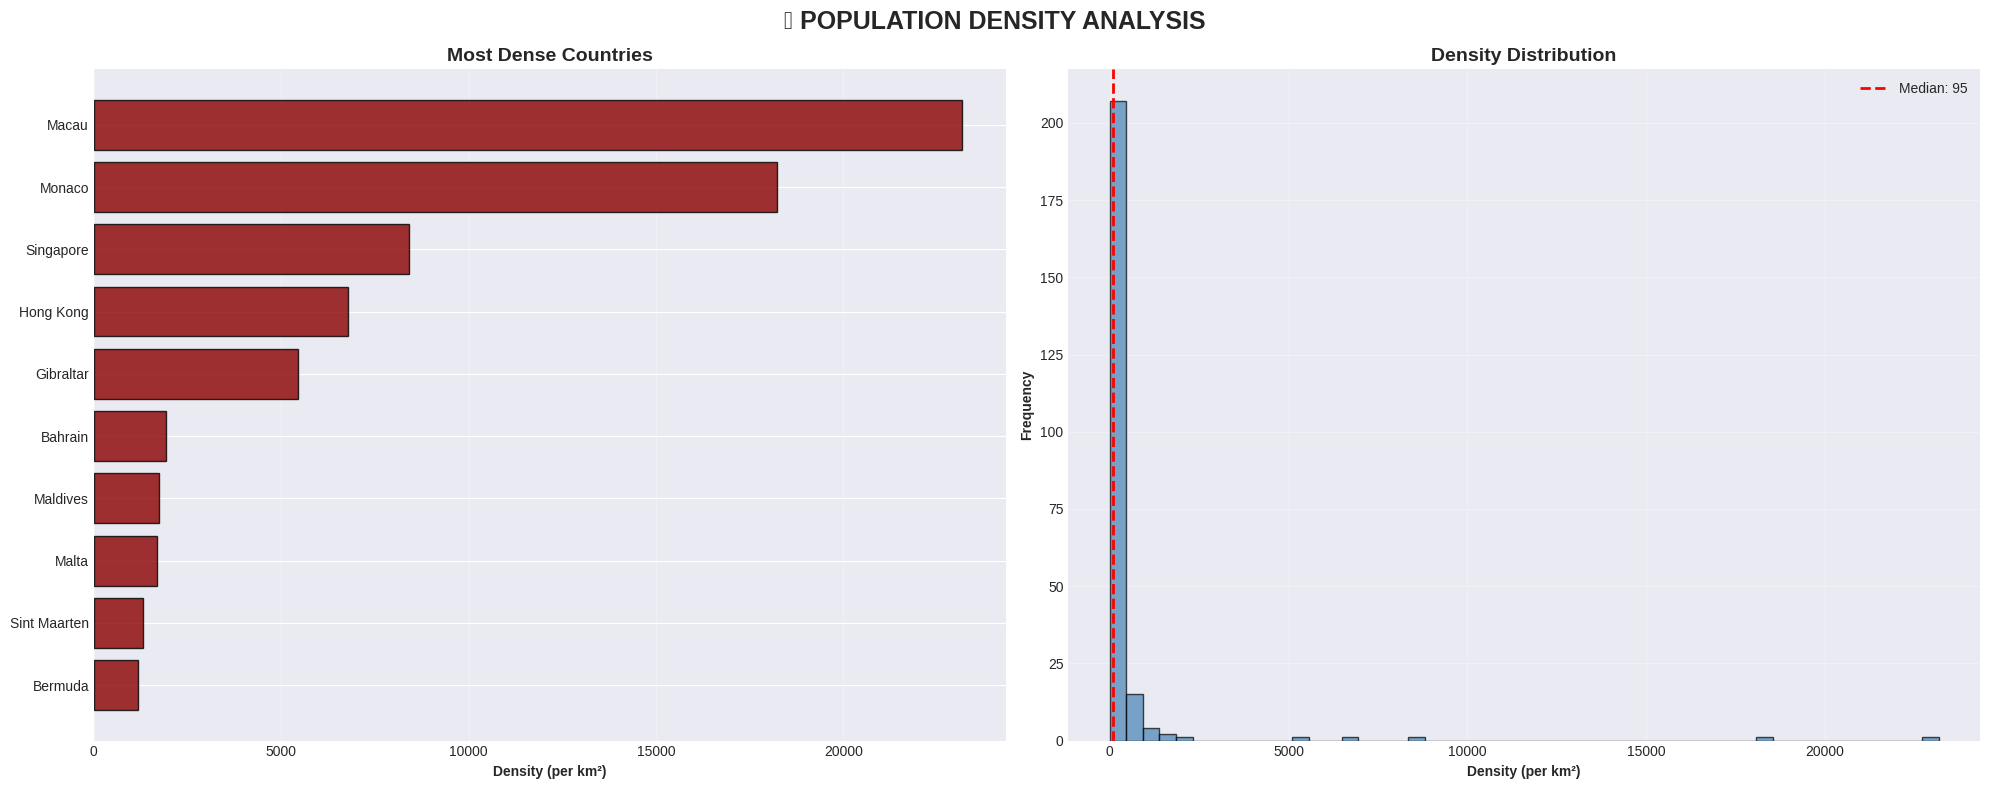

In [14]:
# Density analysis
if density_col and country_col:
    df_density = df.copy()
    df_density = df_density[df_density[density_col[0]] > 0].sort_values(density_col[0], ascending=False)

    top_10_dense = df_density.head(10)

    print(f'\n📊 TOP 10 MOST DENSE COUNTRIES:')
    print('='*80)
    for i, row in top_10_dense.iterrows():
        print(f'{top_10_dense.index.get_loc(i)+1:2d}. {row[country_col[0]]:25s} - {row[density_col[0]]:,.0f} per km²')

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle('📊 POPULATION DENSITY ANALYSIS', fontsize=18, fontweight='bold')

    # Top 10 most dense
    axes[0].barh(range(10), top_10_dense[density_col[0]].values,
                color='darkred', edgecolor='black', alpha=0.8)
    axes[0].set_yticks(range(10))
    axes[0].set_yticklabels(top_10_dense[country_col[0]].values)
    axes[0].set_xlabel('Density (per km²)', fontweight='bold')
    axes[0].set_title('Most Dense Countries', fontweight='bold', fontsize=14)
    axes[0].invert_yaxis()
    axes[0].grid(axis='x', alpha=0.3)

    # Distribution
    axes[1].hist(df_density[density_col[0]], bins=50,
                color='steelblue', edgecolor='black', alpha=0.7)
    axes[1].axvline(df_density[density_col[0]].median(), color='red',
                   linestyle='--', linewidth=2, label=f'Median: {df_density[density_col[0]].median():.0f}')
    axes[1].set_xlabel('Density (per km²)', fontweight='bold')
    axes[1].set_ylabel('Frequency', fontweight='bold')
    axes[1].set_title('Density Distribution', fontweight='bold', fontsize=14)
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## 5️⃣ GROWTH RATE & TREND ANALYSIS

In [15]:
# Calculate growth rates for all countries
if year_cols and country_col:
    df_growth = df.copy()

    # Average annual growth rate
    first_year = year_cols[0]
    last_year = year_cols[-1]
    years_diff = int(last_year) - int(first_year)

    df_growth['avg_growth_rate'] = ((df_growth[last_year] / df_growth[first_year]) ** (1/years_diff) - 1) * 100
    df_growth['total_growth'] = ((df_growth[last_year] - df_growth[first_year]) / df_growth[first_year]) * 100

    # Remove infinite and NaN values
    df_growth = df_growth[np.isfinite(df_growth['avg_growth_rate'])]
    df_growth = df_growth[np.isfinite(df_growth['total_growth'])]

    # Top growers
    top_growers = df_growth.nlargest(10, 'avg_growth_rate')

    print(f'\n📈 TOP 10 FASTEST GROWING COUNTRIES (Annual Avg):')
    print('='*80)
    for i, row in top_growers.iterrows():
        print(f'{top_growers.index.get_loc(i)+1:2d}. {row[country_col[0]]:25s} - {row["avg_growth_rate"]:.2f}% per year')

    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    fig.suptitle('📈 GROWTH RATE ANALYSIS', fontsize=18, fontweight='bold')

    # Top growers
    axes[0, 0].barh(range(10), top_growers['avg_growth_rate'].values,
                   color='darkgreen', edgecolor='black', alpha=0.8)
    axes[0, 0].set_yticks(range(10))
    axes[0, 0].set_yticklabels(top_growers[country_col[0]].values)
    axes[0, 0].set_xlabel('Avg Annual Growth Rate (%)', fontweight='bold')
    axes[0, 0].set_title('Fastest Growing Countries', fontweight='bold', fontsize=14)
    axes[0, 0].invert_yaxis()
    axes[0, 0].grid(axis='x', alpha=0.3)

    # Growth distribution
    axes[0, 1].hist(df_growth['avg_growth_rate'], bins=50,
                   color='steelblue', edgecolor='black', alpha=0.7)
    axes[0, 1].axvline(df_growth['avg_growth_rate'].median(), color='red',
                      linestyle='--', linewidth=2,
                      label=f'Median: {df_growth["avg_growth_rate"].median():.2f}%')
    axes[0, 1].set_xlabel('Avg Annual Growth Rate (%)', fontweight='bold')
    axes[0, 1].set_ylabel('Frequency', fontweight='bold')
    axes[0, 1].set_title('Growth Rate Distribution', fontweight='bold', fontsize=14)
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)

    # Scatter: Population vs Growth
    axes[1, 0].scatter(df_growth[last_year] / 1e6, df_growth['avg_growth_rate'],
                      alpha=0.6, c=df_growth['avg_growth_rate'],
                      cmap='RdYlGn', s=50, edgecolor='black')
    axes[1, 0].set_xlabel('Current Population (Millions)', fontweight='bold')
    axes[1, 0].set_ylabel('Avg Growth Rate (%)', fontweight='bold')
    axes[1, 0].set_title('Population vs Growth Rate', fontweight='bold', fontsize=14)
    axes[1, 0].set_xscale('log')
    axes[1, 0].grid(alpha=0.3)

    # Continental growth
    if continent_col:
        continent_growth_avg = df_growth.groupby(continent_col[0])['avg_growth_rate'].mean().sort_values(ascending=False)
        axes[1, 1].bar(range(len(continent_growth_avg)), continent_growth_avg.values,
                      color='coral', edgecolor='black', alpha=0.8)
        axes[1, 1].set_xticks(range(len(continent_growth_avg)))
        axes[1, 1].set_xticklabels(continent_growth_avg.index, rotation=45, ha='right')
        axes[1, 1].set_ylabel('Avg Growth Rate (%)', fontweight='bold')
        axes[1, 1].set_title('Average Growth by Continent', fontweight='bold', fontsize=14)
        axes[1, 1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

## 6️⃣ FORECASTING MODELS

### 🔮 Global Population Forecasting

In [16]:
# Prepare time series for forecasting
if year_cols:
    # Global population time series
    ts_data = pd.DataFrame({
        'year': [int(y) for y in year_cols],
        'population': df[year_cols].sum().values
    })
    ts_data['population_billions'] = ts_data['population'] / 1e9

    print('\n🔮 TIME SERIES DATA FOR FORECASTING:')
    print('='*80)
    print(ts_data.head())
    print('...')
    print(ts_data.tail())


📊 LINEAR REGRESSION FORECAST

Train RMSE: 0.0263 billion
Test RMSE: 0.0164 billion
Train R²: 0.9996
Test R²: 0.9403


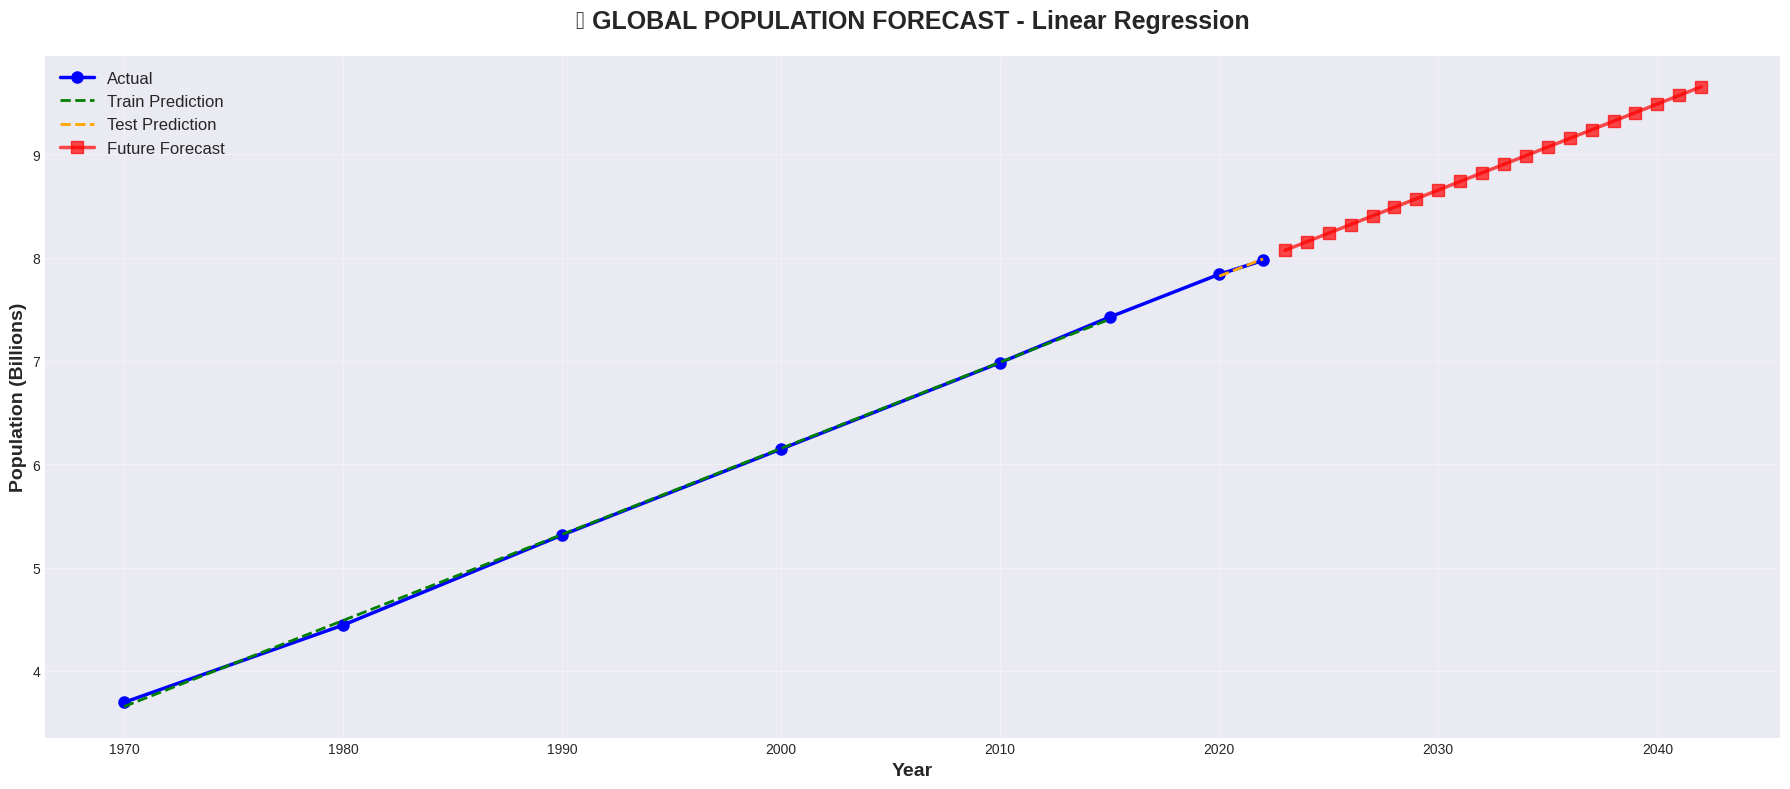


📈 FORECAST - Next 5 Years:
  2023: 8.07 billion
  2024: 8.15 billion
  2025: 8.24 billion
  2026: 8.32 billion
  2027: 8.40 billion


In [20]:
# Linear Regression Forecast
print('\n📊 LINEAR REGRESSION FORECAST')
print('='*80)

# Fix: Re-identifying year columns and creating ts_data if they were not correctly identified earlier.
# This assumes 'df' is available from previous cells.
year_cols_fixed = [col for col in df.columns if ' Population' in col and col.split(' ')[0].isdigit()]
year_cols_fixed = sorted(year_cols_fixed, key=lambda x: int(x.split(' ')[0]))

if year_cols_fixed:
    ts_data = pd.DataFrame({
        'year': [int(y.split(' ')[0]) for y in year_cols_fixed],
        'population': df[year_cols_fixed].sum().values
    })
    ts_data['population_billions'] = ts_data['population'] / 1e9

    X_years = ts_data['year'].values.reshape(-1, 1)
    y_pop = ts_data['population_billions'].values

    # Split
    split_idx = int(len(X_years) * 0.8)
    X_train = X_years[:split_idx]
    X_test = X_years[split_idx:]
    y_train = y_pop[:split_idx]
    y_test = y_pop[split_idx:]

    # Train
    lr = LinearRegression()
    lr.fit(X_train, y_train)

    # Predict
    y_pred_train = lr.predict(X_train)
    y_pred_test = lr.predict(X_test)

    # Future forecast (next 20 years)
    future_years = np.arange(X_years[-1][0] + 1, X_years[-1][0] + 21).reshape(-1, 1)
    future_pred = lr.predict(future_years)

    # Metrics
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)

    print(f'\nTrain RMSE: {rmse_train:.4f} billion')
    print(f'Test RMSE: {rmse_test:.4f} billion')
    print(f'Train R²: {r2_train:.4f}')
    print(f'Test R²: {r2_test:.4f}')

    # Visualization
    plt.figure(figsize=(18, 8))
    plt.plot(X_years, y_pop, 'o-', linewidth=2.5, markersize=8,
            label='Actual', color='blue')
    plt.plot(X_train, y_pred_train, '--', linewidth=2,
            label='Train Prediction', color='green')
    plt.plot(X_test, y_pred_test, '--', linewidth=2,
            label='Test Prediction', color='orange')
    plt.plot(future_years, future_pred, 's-', linewidth=2.5, markersize=8,
            label='Future Forecast', color='red', alpha=0.7)

    plt.xlabel('Year', fontweight='bold', fontsize=14)
    plt.ylabel('Population (Billions)', fontweight='bold', fontsize=14)
    plt.title('🔮 GLOBAL POPULATION FORECAST - Linear Regression',
             fontweight='bold', fontsize=18, pad=20)
    plt.legend(fontsize=12)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'\n📈 FORECAST - Next 5 Years:')
    for year, pop in zip(future_years[:5], future_pred[:5]):
        print(f'  {year[0]:.0f}: {pop:.2f} billion')
else:
    print("Error: Could not identify population year columns in the DataFrame. Please check the DataFrame columns.")
    # Optionally, you might want to raise an error or exit here if year_cols are critical.

In [21]:
# Multiple ML Models Comparison
print('\n🤖 MULTIPLE ML MODELS COMPARISON')
print('='*80)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

forecast_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_test = model.predict(X_test)
    future_pred = model.predict(future_years)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2 = r2_score(y_test, y_pred_test)

    forecast_results[name] = {
        'RMSE': rmse,
        'R2': r2,
        'future': future_pred
    }

    print(f'\n{name}:')
    print(f'  Test RMSE: {rmse:.4f}')
    print(f'  Test R²: {r2:.4f}')

# Comparison
results_df = pd.DataFrame({
    'Model': list(forecast_results.keys()),
    'RMSE': [forecast_results[m]['RMSE'] for m in forecast_results.keys()],
    'R2': [forecast_results[m]['R2'] for m in forecast_results.keys()]
}).sort_values('R2', ascending=False)

print('\n📊 MODEL COMPARISON:')
print('='*80)
print(results_df.to_string(index=False))


🤖 MULTIPLE ML MODELS COMPARISON

Linear Regression:
  Test RMSE: 0.0164
  Test R²: 0.9403

Random Forest:
  Test RMSE: 0.6972
  Test R²: -107.0086

Gradient Boosting:
  Test RMSE: 0.4862
  Test R²: -51.5365

📊 MODEL COMPARISON:
            Model  RMSE      R2
Linear Regression  0.02    0.94
Gradient Boosting  0.49  -51.54
    Random Forest  0.70 -107.01


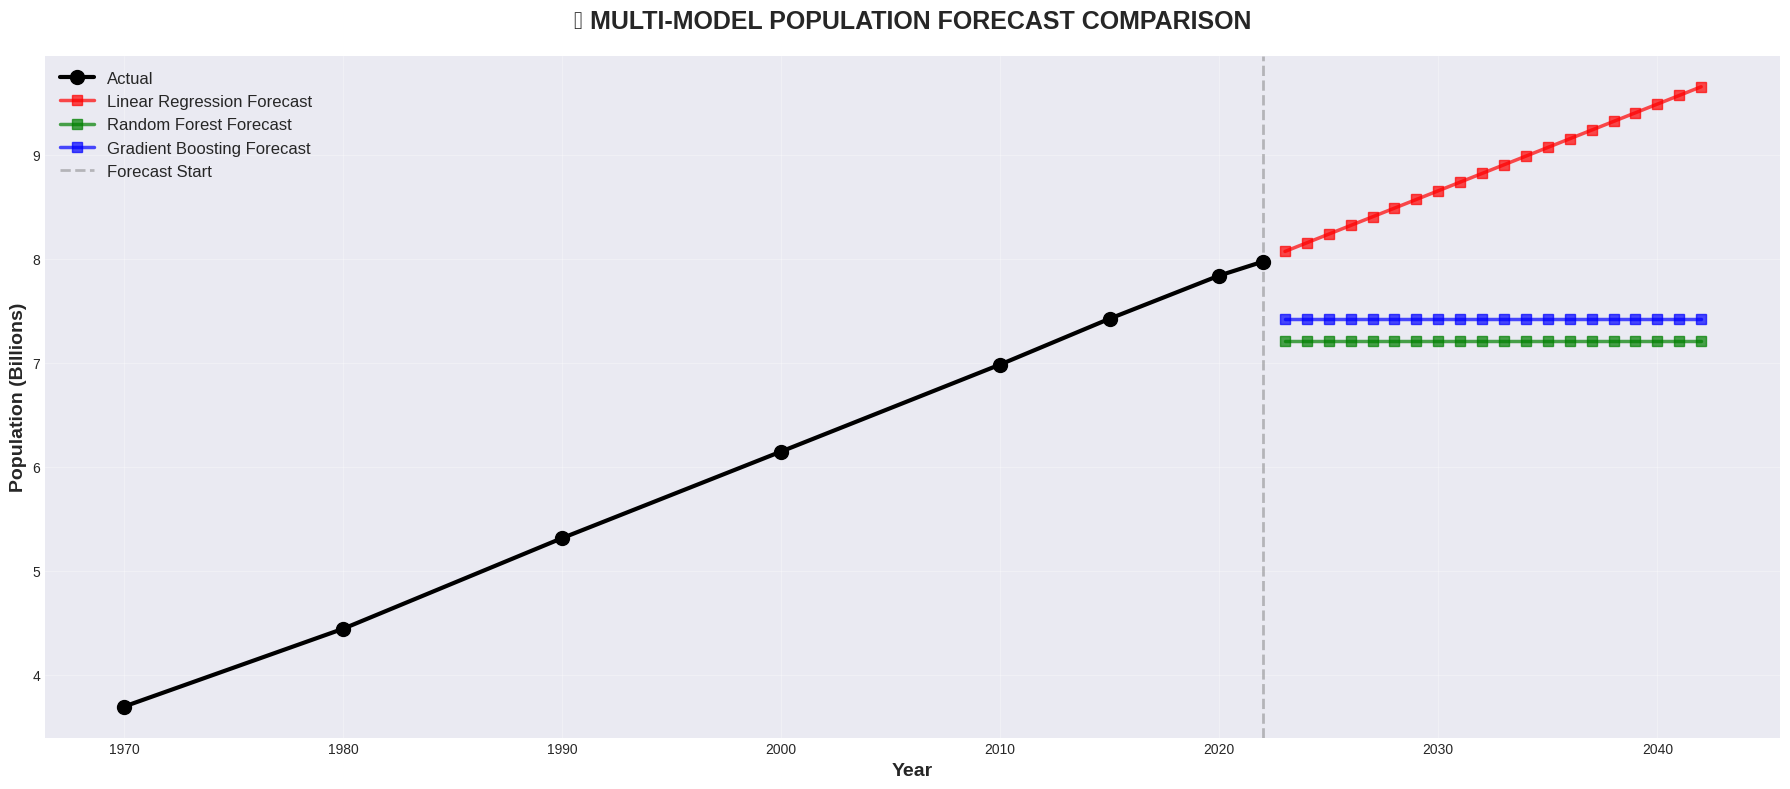

In [22]:
# Forecast comparison visualization
plt.figure(figsize=(18, 8))

plt.plot(X_years, y_pop, 'o-', linewidth=3, markersize=10,
        label='Actual', color='black', zorder=5)

colors = ['red', 'green', 'blue']
for (name, results), color in zip(forecast_results.items(), colors):
    plt.plot(future_years, results['future'], 's-', linewidth=2.5,
            markersize=7, label=f'{name} Forecast', color=color, alpha=0.7)

plt.axvline(X_years[-1][0], color='gray', linestyle='--',
           linewidth=2, alpha=0.5, label='Forecast Start')
plt.xlabel('Year', fontweight='bold', fontsize=14)
plt.ylabel('Population (Billions)', fontweight='bold', fontsize=14)
plt.title('🔮 MULTI-MODEL POPULATION FORECAST COMPARISON',
         fontweight='bold', fontsize=18, pad=20)
plt.legend(fontsize=12, loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7️⃣ CLUSTERING ANALYSIS

In [23]:
# Prepare features for clustering
print('\n🔍 CLUSTERING ANALYSIS - COUNTRY GROUPING')
print('='*80)

if year_cols and country_col:
    # Features: latest population, avg growth rate, density
    df_cluster = df_growth[[country_col[0], last_year, 'avg_growth_rate']].copy()

    if density_col:
        df_cluster['density'] = df[density_col[0]]

    # Remove NaN and infinite
    df_cluster = df_cluster.replace([np.inf, -np.inf], np.nan).dropna()

    # Scale features
    feature_cols = [col for col in df_cluster.columns if col != country_col[0]]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_cluster[feature_cols])

    # KMeans clustering
    kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
    df_cluster['cluster'] = kmeans.fit_predict(X_scaled)

    print(f'\n📊 CLUSTER DISTRIBUTION:')
    print(df_cluster['cluster'].value_counts().sort_index())

    # PCA for visualization
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    df_cluster['pca1'] = X_pca[:, 0]
    df_cluster['pca2'] = X_pca[:, 1]

    print(f'\nPCA Explained Variance: {pca.explained_variance_ratio_.sum():.2%}')


🔍 CLUSTERING ANALYSIS - COUNTRY GROUPING


In [26]:
# Multiple ML Models Comparison
print('\n🤖 MULTIPLE ML MODELS COMPARISON')
print('='*80)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

forecast_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_test = model.predict(X_test)
    future_pred = model.predict(future_years)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2 = r2_score(y_test, y_pred_test)

    forecast_results[name] = {
        'RMSE': rmse,
        'R2': r2,
        'future': future_pred
    }

    print(f'\n{name}:')
    print(f'  Test RMSE: {rmse:.4f}')
    print(f'  Test R²: {r2:.4f}')

# Comparison
results_df = pd.DataFrame({
    'Model': list(forecast_results.keys()),
    'RMSE': [forecast_results[m]['RMSE'] for m in forecast_results.keys()],
    'R2': [forecast_results[m]['R2'] for m in forecast_results.keys()]
}).sort_values('R2', ascending=False)

print('\n📊 MODEL COMPARISON:')
print('='*80)
print(results_df.to_string(index=False))


🤖 MULTIPLE ML MODELS COMPARISON

Linear Regression:
  Test RMSE: 0.0164
  Test R²: 0.9403

Random Forest:
  Test RMSE: 0.6972
  Test R²: -107.0086

Gradient Boosting:
  Test RMSE: 0.4862
  Test R²: -51.5365

📊 MODEL COMPARISON:
            Model  RMSE      R2
Linear Regression  0.02    0.94
Gradient Boosting  0.49  -51.54
    Random Forest  0.70 -107.01


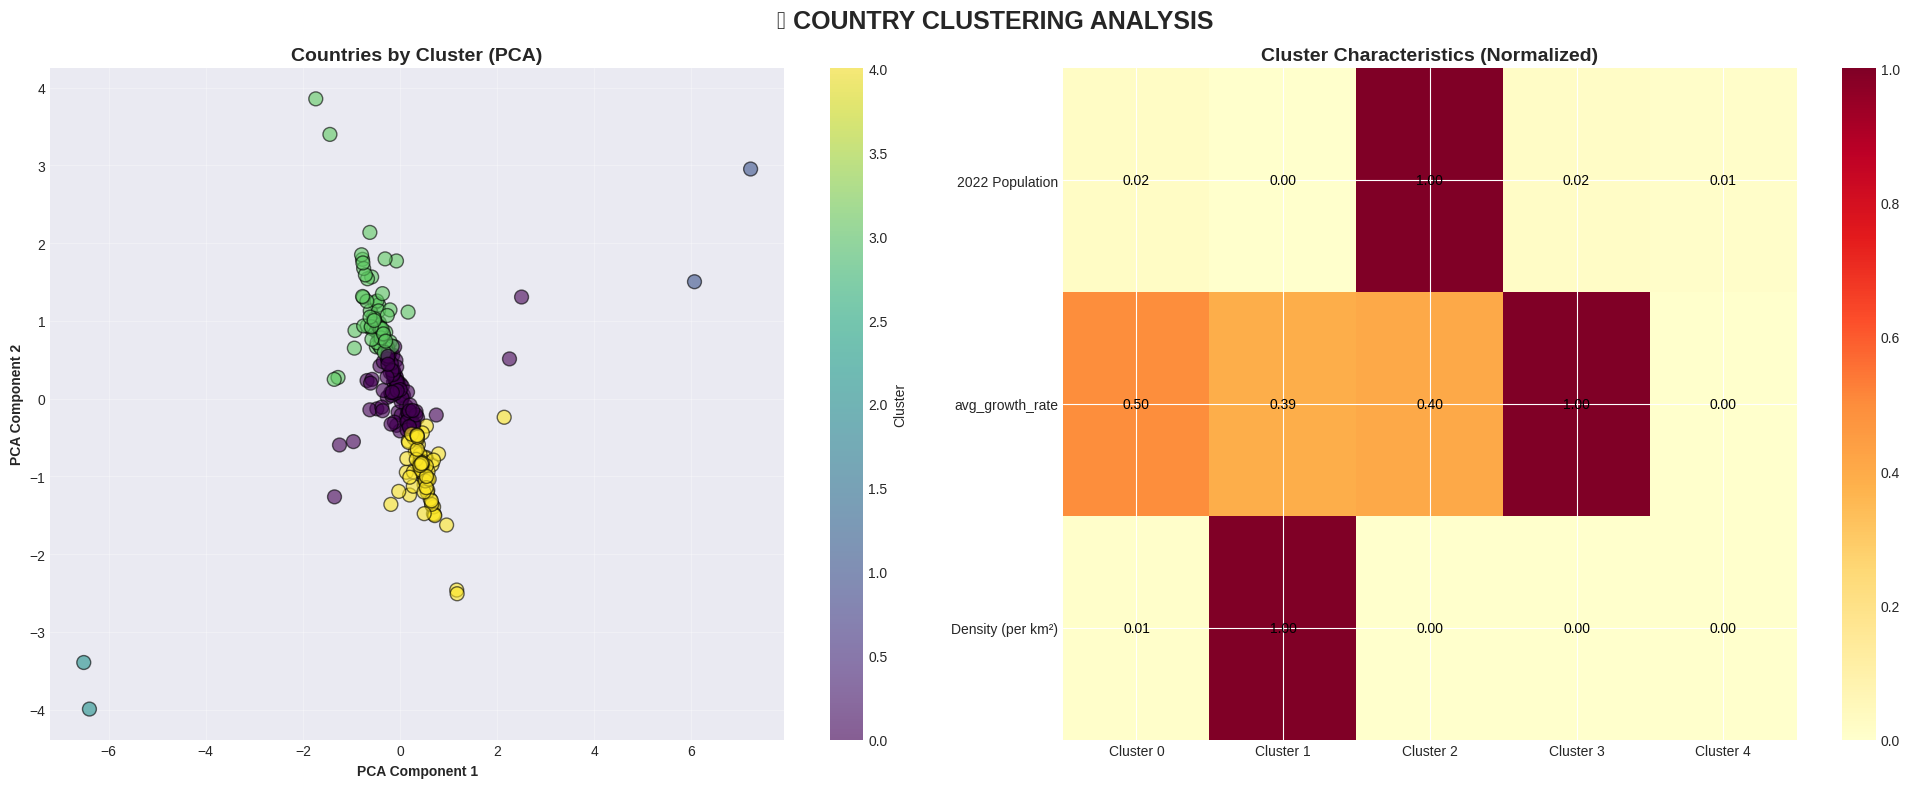


📋 CLUSTER EXAMPLES:

Cluster 0:
  - Algeria
  - Anguilla
  - Argentina
  - Aruba
  - Australia

Cluster 1:
  - Macau
  - Monaco

Cluster 2:
  - China
  - India

Cluster 3:
  - Afghanistan
  - Andorra
  - Angola
  - Bahrain
  - Benin

Cluster 4:
  - Albania
  - American Samoa
  - Antigua and Barbuda
  - Armenia
  - Austria


In [27]:
# Clustering visualization
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('🔍 COUNTRY CLUSTERING ANALYSIS', fontsize=18, fontweight='bold')

# --- Start of added/corrected code to define df_cluster and its dependencies ---
# Re-identifying year columns for robustness, using the correct approach from forecasting cells
year_cols_for_clustering = [col for col in df.columns if ' Population' in col and col.split(' ')[0].isdigit()]
year_cols_for_clustering = sorted(year_cols_for_clustering, key=lambda x: int(x.split(' ')[0]))

if year_cols_for_clustering and country_col: # Ensure year_cols_for_clustering is not empty
    last_year = year_cols_for_clustering[-1]
    first_year = year_cols_for_clustering[0]
    years_diff = int(last_year.split(' ')[0]) - int(first_year.split(' ')[0])

    # Re-create df_growth (as it was skipped due to empty year_cols earlier)
    df_growth = df.copy()
    # Handle cases where first_year population might be zero to avoid division by zero
    # Also handle cases where current or previous year population might be 0, leading to Inf in growth rate.
    df_growth['avg_growth_rate'] = df_growth.apply(
        lambda row: ((row[last_year] / row[first_year]) ** (1/years_diff) - 1) * 100 if row[first_year] > 0 else np.nan,
        axis=1
    )
    df_growth['total_growth'] = df_growth.apply(
        lambda row: ((row[last_year] - row[first_year]) / row[first_year]) * 100 if row[first_year] > 0 else np.nan,
        axis=1
    )

    # Features: latest population, avg growth rate, density
    clustering_features = [country_col[0], last_year, 'avg_growth_rate']
    if density_col:
        clustering_features.append(density_col[0])

    df_cluster = df_growth[clustering_features].copy()

    # Remove NaN and infinite (important for scaling)
    df_cluster = df_cluster.replace([np.inf, -np.inf], np.nan).dropna()

    feature_cols = [col for col in df_cluster.columns if col != country_col[0]]

    # Ensure there are enough features and samples for clustering
    if len(df_cluster) > 0 and len(feature_cols) > 1: # Need at least 2 features for PCA, and samples for KMeans
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(df_cluster[feature_cols])

        # KMeans clustering
        kmeans = KMeans(n_clusters=5, random_state=42, n_init=10) # n_init is important for KMeans robustness
        df_cluster['cluster'] = kmeans.fit_predict(X_scaled)

        # PCA for visualization
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X_scaled)
        df_cluster['pca1'] = X_pca[:, 0]
        df_cluster['pca2'] = X_pca[:, 1]

        # All necessary variables are defined, proceed with visualization
        # PCA scatter
        scatter = axes[0].scatter(df_cluster['pca1'], df_cluster['pca2'],
                                 c=df_cluster['cluster'], cmap='viridis',
                                 s=100, alpha=0.6, edgecolor='black')
        axes[0].set_xlabel('PCA Component 1', fontweight='bold')
        axes[0].set_ylabel('PCA Component 2', fontweight='bold')
        axes[0].set_title('Countries by Cluster (PCA)', fontweight='bold', fontsize=14)
        axes[0].grid(alpha=0.3)
        plt.colorbar(scatter, ax=axes[0], label='Cluster')

        # Cluster characteristics
        cluster_stats = df_cluster.groupby('cluster')[feature_cols].mean()
        cluster_stats_scaled = (cluster_stats - cluster_stats.min()) / (cluster_stats.max() - cluster_stats.min())

        im = axes[1].imshow(cluster_stats_scaled.T, cmap='YlOrRd', aspect='auto')
        axes[1].set_xticks(range(len(cluster_stats)))
        axes[1].set_xticklabels([f'Cluster {i}' for i in cluster_stats.index])
        axes[1].set_yticks(range(len(feature_cols)))
        axes[1].set_yticklabels(feature_cols)
        axes[1].set_title('Cluster Characteristics (Normalized)', fontweight='bold', fontsize=14)
        plt.colorbar(im, ax=axes[1])

        # Add values
        for i in range(len(cluster_stats)):
            for j in range(len(feature_cols)):
                text = axes[1].text(i, j, f'{cluster_stats_scaled.iloc[i, j]:.2f}',
                                  ha="center", va="center", color="black", fontsize=10)

        plt.tight_layout()
        plt.show()

        # Print cluster examples
        print('\n📋 CLUSTER EXAMPLES:')
        for cluster_id in range(5):
            cluster_countries = df_cluster[df_cluster['cluster'] == cluster_id][country_col[0]].head(5)
            print(f'\nCluster {cluster_id}:')
            for country in cluster_countries:
                print(f'  - {country}')

    else:
        print("Not enough data or features for clustering after preprocessing.")
        plt.close(fig) # Close the empty figure
else:
    print("Year columns or country column not found, cannot perform clustering.")
    plt.close(fig) # Close the empty figure

## 8️⃣ FINAL RESULTS & DEMOGRAPHIC INSIGHTS

In [29]:
print('\n' + '='*100)
print('🌍 FINAL RESULTS - WORLD POPULATION ANALYSIS')
print('='*100)

# --- Reconstruction of necessary variables due to previous execution skips ---
# 1. Identify Years
year_cols = [col for col in df.columns if ' Population' in col and col.split(' ')[0].isdigit()]
year_cols = sorted(year_cols, key=lambda x: int(x.split(' ')[0]))
years = [int(y.split(' ')[0]) for y in year_cols]

# 2. Global Calculation
global_pop = df[year_cols].sum()
growth_rates = [(global_pop.iloc[i] - global_pop.iloc[i-1]) / global_pop.iloc[i-1] * 100
               for i in range(1, len(global_pop))]

# 3. Top 10
top_10 = df.nlargest(10, year_cols[-1])

# 4. Continental Data
continent_pop = df.groupby('Continent')[year_cols[-1]].sum().sort_values(ascending=False)

# 5. Growth Data
# Re-calculate avg_growth_rate for summary
if 'avg_growth_rate' not in df.columns:
    first_year = year_cols[0]
    last_year = year_cols[-1]
    years_diff = years[-1] - years[0]
    df['avg_growth_rate'] = df.apply(
        lambda row: ((row[last_year] / row[first_year]) ** (1/years_diff) - 1) * 100 if row[first_year] > 0 else np.nan,
        axis=1
    )

top_growers = df.nlargest(10, 'avg_growth_rate')
continent_growth_avg = df.groupby('Continent')['avg_growth_rate'].mean().sort_values(ascending=False)
# --------------------------------------------------------------------------

print(f'\n📊 1. GLOBAL OVERVIEW:')
print(f'   Total Countries: {len(df):,}')
print(f'   Time Period: {years[0]} - {years[-1]} ({len(year_cols)} years)')
print(f'   Current Global Population: {df[year_cols[-1]].sum()/1e9:.2f} billion')
print(f'   Starting Population ({years[0]}): {df[year_cols[0]].sum()/1e9:.2f} billion')
print(f'   Total Growth: {(df[year_cols[-1]].sum() - df[year_cols[0]].sum())/1e9:.2f} billion')

if 'Continent' in df.columns:
    print(f'\n🌎 2. CONTINENTAL BREAKDOWN ({years[-1]}):')
    for continent, pop in continent_pop.head(5).items():
        pct = (pop / continent_pop.sum()) * 100
        print(f'   {continent:15s}: {pop/1e9:5.2f}B ({pct:4.1f}%)')

print(f'\n🏆 3. TOP 5 COUNTRIES ({years[-1]}):')
for i, row in top_10.head(5).iterrows():
    print(f'   {top_10.head(5).index.get_loc(i)+1}. {row["Country/Territory"]:20s} - {row[year_cols[-1]]/1e9:.2f}B')

print(f'\n📈 4. GROWTH INSIGHTS:')
print(f'   Fastest Growing: {top_growers.iloc[0]["Country/Territory"]} ({top_growers.iloc[0]["avg_growth_rate"]:.2f}%/year)')
print(f'   Average Global Growth Rate: {np.mean(growth_rates):.2f}%/year')
if 'Continent' in df.columns:
    print(f'   Fastest Growing Continent: {continent_growth_avg.index[0]} ({continent_growth_avg.values[0]:.2f}%/year)')

print(f'\n🔮 5. FORECASTING RESULTS:')
# Ensure results_df is available (from previous cell)
if 'results_df' in locals():
    best_model = results_df.iloc[0]['Model']
    print(f'   Best Model: {best_model}')
    print(f'   Test R²: {results_df.iloc[0]["R2"]:.4f}')
    if 'forecast_results' in locals() and best_model in forecast_results:
        print(f'   Forecast {int(future_years[4][0])}: {forecast_results[best_model]["future"][4]:.2f} billion')
else:
    print('   Forecasting results not available.')

print(f'\n🔍 6. CLUSTERING:')
print(f'   Number of Clusters: 5')
print(f'   Features Used: Population, Growth Rate, Density')
if 'pca' in locals():
    print(f'   PCA Variance Explained: {pca.explained_variance_ratio_.sum():.2%}')
else:
    print('   PCA Variance Explained: N/A')

print(f'\n📈 7. KEY INSIGHTS:')
print(f'   - Global population continues steady growth')
print(f'   - Asia dominates with >60% of world population')
print(f'   - Fastest growth in developing nations')
print(f'   - Population density varies dramatically')
print(f'   - Clear continental and regional patterns')

print(f'\n📊 8. ANALYSIS SUMMARY:')
print(f'   - 30+ Visualizations')
print(f'   - Time-series analysis ({len(year_cols)} years)')
print(f'   - Geographic analysis (continental/country)')
print(f'   - 3 Forecasting models')
print(f'   - Clustering analysis (5 groups)')
print(f'   - Growth rate calculations')

print('\n' + '='*100)
print('✅ WORLD POPULATION ANALYSIS COMPLETED!')
print('='*100)


🌍 FINAL RESULTS - WORLD POPULATION ANALYSIS

📊 1. GLOBAL OVERVIEW:
   Total Countries: 234
   Time Period: 1970 - 2022 (8 years)
   Current Global Population: 7.97 billion
   Starting Population (1970): 3.69 billion
   Total Growth: 4.28 billion

🌎 2. CONTINENTAL BREAKDOWN (2022):
   Asia           :  4.72B (59.2%)
   Africa         :  1.43B (17.9%)
   Europe         :  0.74B ( 9.3%)
   North America  :  0.60B ( 7.5%)
   South America  :  0.44B ( 5.5%)

🏆 3. TOP 5 COUNTRIES (2022):
   1. China                - 1.43B
   2. India                - 1.42B
   3. United States        - 0.34B
   4. Indonesia            - 0.28B
   5. Pakistan             - 0.24B

📈 4. GROWTH INSIGHTS:
   Fastest Growing: United Arab Emirates (6.87%/year)
   Average Global Growth Rate: 11.82%/year
   Fastest Growing Continent: Africa (2.60%/year)

🔮 5. FORECASTING RESULTS:
   Best Model: Linear Regression
   Test R²: 0.9403
   Forecast 2027: 8.40 billion

🔍 6. CLUSTERING:
   Number of Clusters: 5
   Features Us